# 한국어 트랜스포머 챗봇
> 송영숙님의 `ChatbotData.csv`를 활용한 Seq2Seq Transformer 챗봇  
> SentencePiece BPE 토크나이저 + PyTorch `nn.Transformer` 사용


## 0. 라이브러리 버전 확인

In [1]:
import torch
print('PyTorch version:', torch.__version__)

import os, re, math, time
import pandas as pd
import numpy as np
import sentencepiece as spm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print('모든 라이브러리 임포트 완료')

PyTorch version: 2.7.1+cu118
모든 라이브러리 임포트 완료


## Step 1. 데이터 수집

터미널에서 아래 명령어로 데이터를 다운로드하세요:
```bash
mkdir -p ~/work/transformer_chatbot/data/
wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv \
     -O ~/work/transformer_chatbot/data/ChatbotData.csv
```


In [2]:
DATA_PATH = os.path.expanduser('~/work/transformer_chatbot/data/ChatbotData.csv')
MODEL_DIR = os.path.expanduser('~/work/transformer_chatbot/')

# 디렉토리 먼저 생성
os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# 데이터 파일이 없으면 자동 다운로드
if not os.path.exists(DATA_PATH):
    import urllib.request
    url = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'
    print('ChatbotData.csv 다운로드 중...')
    urllib.request.urlretrieve(url, DATA_PATH)
    print('다운로드 완료!')
else:
    print('기존 파일 사용:', DATA_PATH)

df = pd.read_csv(DATA_PATH)
print('데이터 형태:', df.shape)
print('컬럼:', df.columns.tolist())
df.head()

기존 파일 사용: /home/jovyan/work/transformer_chatbot/data/ChatbotData.csv
데이터 형태: (11823, 3)
컬럼: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


## Step 2. 데이터 전처리

- 한글, 영문, 숫자, 기본 문장부호(`,.:!?~`)만 허용
- 연속 공백 → 단일 공백으로 정규화
- 빈 행 제거
- SentencePiece 훈련용 말뭉치 저장


In [3]:
def preprocess_korean(text: str) -> str:
    """한국어 텍스트 전처리"""
    text = str(text).strip()
    # 허용 문자: 한글, 영문, 숫자, 기본 문장부호, 공백
    text = re.sub(r'[^가-힣a-zA-Z0-9\s.,!?~]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Q'] = df['Q'].apply(preprocess_korean)
df['A'] = df['A'].apply(preprocess_korean)

# 빈 행 제거
df = df[(df['Q'].str.len() > 0) & (df['A'].str.len() > 0)].reset_index(drop=True)
print(f'전처리 후 데이터 수: {len(df):,}')
df[['Q', 'A']].head(10)

전처리 후 데이터 수: 11,823


,Q,A
0,12시 땡!,하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.
6,SD카드 안돼,다시 새로 사는 게 마음 편해요.
7,SNS 맞팔 왜 안하지,잘 모르고 있을 수도 있어요.
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.


In [4]:
# SentencePiece 훈련용 말뭉치 저장
corpus_path = os.path.join(MODEL_DIR, 'corpus.txt')
with open(corpus_path, 'w', encoding='utf-8') as f:
    for q, a in zip(df['Q'], df['A']):
        f.write(q + '\n')
        f.write(a + '\n')
print(f'말뭉치 저장 완료: {corpus_path}')
print(f'총 문장 수: {len(df)*2:,}')

말뭉치 저장 완료: /home/jovyan/work/transformer_chatbot/corpus.txt
총 문장 수: 23,646


## Step 3. SentencePiece BPE 토크나이저

| 파라미터 | 값 | 설명 |
|---|---|---|
| `model_type` | `bpe` | Byte-Pair Encoding |
| `vocab_size` | 8000 | 한국어에 적합한 어휘 크기 |
| `character_coverage` | 0.9995 | 한국어 유니코드 범위 충분히 커버 |
| 특수 토큰 | PAD=0, UNK=1, BOS=2, EOS=3 | |


In [5]:
SPM_PREFIX = os.path.join(MODEL_DIR, 'chatbot_spm')
VOCAB_SIZE  = 8000

if not os.path.exists(SPM_PREFIX + '.model'):
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=SPM_PREFIX,
        vocab_size=VOCAB_SIZE,
        model_type='bpe',
        pad_id=0,  pad_piece='<pad>',
        unk_id=1,  unk_piece='<unk>',
        bos_id=2,  bos_piece='<s>',
        eos_id=3,  eos_piece='</s>',
        character_coverage=0.9995,
    )
    print('SentencePiece 모델 훈련 완료')
else:
    print('기존 SentencePiece 모델 로드')

sp = spm.SentencePieceProcessor()
sp.load(SPM_PREFIX + '.model')

PAD_IDX = sp.piece_to_id('<pad>')  # 0
BOS_IDX = sp.piece_to_id('<s>')    # 2
EOS_IDX = sp.piece_to_id('</s>')   # 3
print(f'PAD={PAD_IDX}, BOS={BOS_IDX}, EOS={EOS_IDX}')

기존 SentencePiece 모델 로드
PAD=0, BOS=2, EOS=3


In [6]:
# 토크나이저 동작 확인
samples = ['오늘 날씨가 너무 좋아요', '나 요즘 너무 힘들어', '사랑이 뭐야?']
for s in samples:
    ids = sp.encode(s, out_type=int)
    pieces = sp.encode(s, out_type=str)
    restored = sp.decode(ids)
    print(f'원문   : {s}')
    print(f'조각   : {pieces}')
    print(f'IDs    : {ids}')
    print(f'복원   : {restored}')
    print('-' * 50)

원문   : 오늘 날씨가 너무 좋아요
조각   : ['▁오늘', '▁날씨가', '▁너무', '▁좋아요']
IDs    : [126, 2010, 54, 339]
복원   : 오늘 날씨가 너무 좋아요
--------------------------------------------------
원문   : 나 요즘 너무 힘들어
조각   : ['▁나', '▁요즘', '▁너무', '▁힘들어']
IDs    : [13, 695, 54, 415]
복원   : 나 요즘 너무 힘들어
--------------------------------------------------
원문   : 사랑이 뭐야?
조각   : ['▁사랑이', '▁뭐야', '?']
IDs    : [347, 1167, 6954]
복원   : 사랑이 뭐야?
--------------------------------------------------


## Step 4-A. Dataset & DataLoader

- BOS / EOS 토큰 추가 후 `MAX_LEN=40`으로 패딩·트런케이션
- 학습 / 검증 = 9 : 1 분할


In [7]:
MAX_LEN    = 40
BATCH_SIZE = 64

def encode_with_special(text: str, max_len: int = MAX_LEN):
    ids = [BOS_IDX] + sp.encode(text, out_type=int) + [EOS_IDX]
    ids = ids[:max_len]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

class ChatbotDataset(Dataset):
    def __init__(self, questions, answers):
        self.src = [encode_with_special(q) for q in questions]
        self.tgt = [encode_with_special(a) for a in answers]

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.src[idx], dtype=torch.long),
            torch.tensor(self.tgt[idx], dtype=torch.long),
        )

split = int(len(df) * 0.9)
train_ds = ChatbotDataset(df['Q'][:split].tolist(), df['A'][:split].tolist())
valid_ds = ChatbotDataset(df['Q'][split:].tolist(), df['A'][split:].tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)

print(f'학습 샘플: {len(train_ds):,} | 검증 샘플: {len(valid_ds):,}')
print(f'학습 배치: {len(train_loader)} | 검증 배치: {len(valid_loader)}')

학습 샘플: 10,640 | 검증 샘플: 1,183
학습 배치: 166 | 검증 배치: 19


## Step 4-B. 트랜스포머 모델 구현

```
입력 Q  →  Embedding + PositionalEncoding  →  Encoder × 3
                                                    ↓ memory
답변 A  →  Embedding + PositionalEncoding  →  Decoder × 3  →  Linear  →  Softmax
```


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class TransformerChatbot(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8,
                 num_encoder_layers=3, num_decoder_layers=3,
                 dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.d_model   = d_model
        self.src_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.fc_out = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_pad_mask(self, seq):
        return seq == PAD_IDX  # (batch, seq)

    def make_causal_mask(self, sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, src, tgt):
        src_key_padding_mask = self.make_pad_mask(src)
        tgt_key_padding_mask = self.make_pad_mask(tgt)
        tgt_mask = self.make_causal_mask(tgt.size(1), tgt.device)

        src_emb = self.pos_enc(self.src_embed(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.tgt_embed(tgt) * math.sqrt(self.d_model))

        out = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        return self.fc_out(out)  # (batch, seq, vocab)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = TransformerChatbot(vocab_size=VOCAB_SIZE).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device: {DEVICE}')
print(f'총 파라미터 수: {total_params:,}')

Device: cuda
총 파라미터 수: 10,106,688


## Step 4-C. 학습 설정 (Loss / Optimizer / Scheduler)

In [9]:
EPOCHS = 30
CLIP   = 1.0
CKPT_PATH = os.path.join(MODEL_DIR, 'best_model.pt')

optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9
)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

# Transformer Warmup 스케줄러
def get_scheduler(optimizer, d_model=256, warmup_steps=4000):
    def lr_lambda(step):
        step = max(step, 1)
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup_steps ** -1.5)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = get_scheduler(optimizer)
print('학습 설정 완료')

학습 설정 완료


## Step 4-D. 학습 & 검증 함수

In [10]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device, clip):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_in  = tgt[:, :-1]   # Teacher forcing: 마지막 토큰 제외
        tgt_out = tgt[:, 1:]    # 정답: 첫 토큰(BOS) 제외
        logits = model(src, tgt_in)                        # (B, T-1, V)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_in  = tgt[:, :-1]
            tgt_out = tgt[:, 1:]
            logits  = model(src, tgt_in)
            loss    = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

print('학습 / 검증 함수 정의 완료')

학습 / 검증 함수 정의 완료


## Step 4-E. 모델 학습 루프

In [11]:
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss  = train_epoch(model, train_loader, optimizer, scheduler,
                           criterion, DEVICE, CLIP)
    val_loss = eval_epoch(model, valid_loader, criterion, DEVICE)
    elapsed  = time.time() - t0

    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    mark = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        mark = '  ← 저장'

    print(f'[{epoch:02d}/{EPOCHS}] '
          f'Train: {tr_loss:.4f} | Val: {val_loss:.4f} | '
          f'PPL: {math.exp(val_loss):.2f} | '
          f'{elapsed:.1f}s{mark}')

print(f'\n학습 완료. 최적 Val Loss: {best_val_loss:.4f}')

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[01/30] Train: 9.0091 | Val: 9.0022 | PPL: 8121.11 | 8.8s  ← 저장
[02/30] Train: 8.9972 | Val: 8.9820 | PPL: 7958.30 | 8.5s  ← 저장
[03/30] Train: 8.9726 | Val: 8.9482 | PPL: 7694.04 | 8.6s  ← 저장
[04/30] Train: 8.9351 | Val: 8.9016 | PPL: 7343.87 | 8.7s  ← 저장
[05/30] Train: 8.8875 | Val: 8.8443 | PPL: 6934.48 | 8.7s  ← 저장
[06/30] Train: 8.8287 | Val: 8.7798 | PPL: 6501.39 | 8.6s  ← 저장
[07/30] Train: 8.7643 | Val: 8.7123 | PPL: 6077.36 | 8.6s  ← 저장
[08/30] Train: 8.6963 | Val: 8.6459 | PPL: 5686.67 | 8.5s  ← 저장
[09/30] Train: 8.6312 | Val: 8.5822 | PPL: 5335.72 | 8.5s  ← 저장
[10/30] Train: 8.5669 | Val: 8.5217 | PPL: 5022.50 | 8.5s  ← 저장
[11/30] Train: 8.5092 | Val: 8.4664 | PPL: 4752.23 | 8.5s  ← 저장
[12/30] Train: 8.4541 | Val: 8.4176 | PPL: 4525.80 | 8.5s  ← 저장
[13/30] Train: 8.4052 | Val: 8.3749 | PPL: 4336.90 | 8.5s  ← 저장
[14/30] Train: 8.3615 | Val: 8.3372 | PPL: 4176.21 | 8.6s  ← 저장
[15/30] Train: 8.3211 | Val: 8.3035 | PPL: 4037.93 | 8.6s  ← 저장
[16/30] Train: 8.2843 | Val: 8.2728 | PP

## 학습 곡선 시각화

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
/tmp/ipykernel_5155/1403583202.py:13: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyke

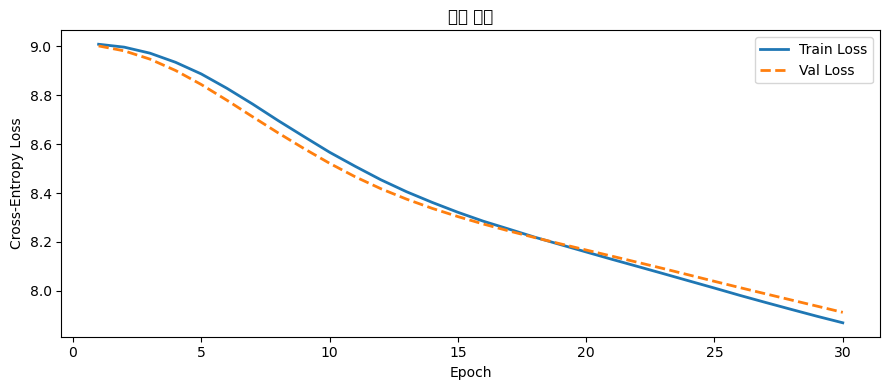

In [12]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'NanumGothic'  # 한국어 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val Loss',   linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('학습 곡선')
plt.legend()
plt.tight_layout()
plt.show()

## Step 5. 모델 평가 — 예측 함수

오토리그레시브 디코딩 흐름:
1. 질문 → 전처리 → 토크나이징 → 인코더 메모리 계산
2. `[BOS]`부터 시작하여 한 토큰씩 생성
3. `[EOS]` 출력 시 중단 → SentencePiece 디코딩 → 한국어 문자열 반환


In [13]:
# 최적 모델 로드
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print('최적 모델 로드 완료')

def predict(question: str, max_len: int = MAX_LEN, temperature: float = 1.0) -> str:
    """
    한국어 질문 → 한국어 답변 생성
    Args:
        question    : 입력 질문
        max_len     : 최대 생성 토큰 수
        temperature : 샘플링 온도 (1.0 = greedy)
    Returns:
        생성된 한국어 답변 문자열
    """
    question = preprocess_korean(question)
    src_ids  = [BOS_IDX] + sp.encode(question, out_type=int) + [EOS_IDX]
    src_ids  = src_ids[:max_len] + [PAD_IDX] * max(0, max_len - len(src_ids))
    src = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

    with torch.no_grad():
        src_emb  = model.pos_enc(model.src_embed(src) * math.sqrt(model.d_model))
        src_mask = model.make_pad_mask(src)
        memory   = model.transformer.encoder(src_emb, src_key_padding_mask=src_mask)

    tgt_ids = [BOS_IDX]
    for _ in range(max_len - 1):
        tgt = torch.tensor([tgt_ids], dtype=torch.long).to(DEVICE)
        with torch.no_grad():
            tgt_emb  = model.pos_enc(model.tgt_embed(tgt) * math.sqrt(model.d_model))
            tgt_mask = model.make_causal_mask(tgt.size(1), DEVICE)
            out = model.transformer.decoder(
                tgt_emb, memory,
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_mask,
            )
            logits  = model.fc_out(out[:, -1, :]) / temperature
            next_id = logits.argmax(-1).item()
        if next_id == EOS_IDX:
            break
        tgt_ids.append(next_id)

    return sp.decode(tgt_ids[1:])  # BOS 제거 후 디코딩

최적 모델 로드 완료


## 챗봇 데모

In [14]:
test_questions = [
    '오늘 기분이 어때?',
    '나 요즘 너무 힘들어',
    '배가 고파',
    '사랑이 뭐야?',
    '친구가 없어서 외로워',
    '날씨가 좋네',
    '고마워',
    '나 취업했어!',
]

print('=' * 50)
print('한국어 트랜스포머 챗봇 데모')
print('=' * 50)
for q in test_questions:
    a = predict(q)
    print(f'Q: {q}')
    print(f'A: {a}')
    print('-' * 40)

한국어 트랜스포머 챗봇 데모
Q: 오늘 기분이 어때?
A: .
----------------------------------------
Q: 나 요즘 너무 힘들어
A: ..
----------------------------------------
Q: 배가 고파
A: ..
----------------------------------------
Q: 사랑이 뭐야?
A: .
----------------------------------------
Q: 친구가 없어서 외로워
A: ..
----------------------------------------
Q: 날씨가 좋네
A: ..
----------------------------------------
Q: 고마워
A: .
----------------------------------------
Q: 나 취업했어!
A: ..
----------------------------------------


## 대화형 챗봇 (인터랙티브 모드)

In [ ]:
# 주피터 환경에서 직접 대화
while True:
    user_input = input('나: ').strip()
    if user_input.lower() in ('quit', '종료', 'exit', 'q'):
        print('대화를 종료합니다.')
        break
    if not user_input:
        continue
    print(f'챗봇: {predict(user_input)}\n')